### **Comparando Modelos**

In [1]:
# Importando Bibliotecas
import os
import pickle

from src.utils import set_seed
from src.evalutation.model_comparator import ModelComparator

set_seed(42)

### **Selecionando Modelos a serem comparados**

In [2]:
# Escolhendo modelos single-stage para comparar:
list_models_single_stage = [r"data\model_weights\UNet_ImageNet\FocalMSELoss_1ep\1783093205",
                            r"data\model_weights\FullHRNet_ImageNet\MSELoss_200ep_32W\1791552534",
]

# Escolhendo modelos dois estágios para comparar:
list_models_two_stage = [
    (r"data\model_weights\GlobalStageWrapper\MSELoss_80ep\1790014927", r"data\model_weights\LocalStageWrapper\MSELoss_80ep\1790014928"),
]

In [3]:
# Coletando Configurações dos modelos single-stage:
dict_config = {}
for model in list_models_single_stage:
    with open(os.path.join(model,'config.pkl'), 'rb') as f:
        config_model = pickle.load(f)
        dict_config[model] = config_model

# Coletando Configurações dos modelos dois estágios:
for (stage1_dir, stage2_dir) in list_models_two_stage:
    with open(os.path.join(stage1_dir, 'config.pkl'), 'rb') as f:
        config_stage1 = pickle.load(f)
    with open(os.path.join(stage2_dir, 'config.pkl'), 'rb') as f:
        config_stage2 = pickle.load(f)
    # Chave = diretório do stage1; valor = tupla de configs
    dict_config[stage1_dir] = (config_stage1, config_stage2)

### **Comparando Resultados - Métricas**

In [4]:
# Criando objeto de comparação
comp = ModelComparator(dict_config=dict_config)
dfMetrics = comp.calculate_metrics()

✓ Modelo carregado: data\model_weights\UNet_ImageNet\FocalMSELoss_1ep\1783093205\fold_1_best.pth
  Epoch: 0
  Val Loss: 0.0307

Avaliando 178 amostras do conjunto de teste...


Avaliando: 100%|██████████| 178/178 [00:09<00:00, 19.42it/s]


HRNet 32 inicializada com 39 camadas da ImageNet.
✓ Modelo carregado: data\model_weights\FullHRNet_ImageNet\MSELoss_200ep_32W\1791552534\fold_1_best.pth
  Epoch: 26
  Val Loss: 0.0009

Avaliando 178 amostras do conjunto de teste...


Avaliando: 100%|██████████| 178/178 [00:05<00:00, 31.52it/s]


✓ Stage 1 carregado: data\model_weights\GlobalStageWrapper\MSELoss_80ep\1790014927\fold_1_best.pth
  Epoch: 64 | Val Loss: 0.0033
✓ Stage 2 carregado: data\model_weights\LocalStageWrapper\MSELoss_80ep\1790014928\fold_1_best.pth
  Epoch: 74 | Val Loss: 0.0267

AVALIANDO PIPELINE TWO-STAGE NO CONJUNTO DE TESTE

Avaliando 178 amostras (two-stage)…


Avaliando: 100%|██████████| 178/178 [00:17<00:00, 10.21it/s]


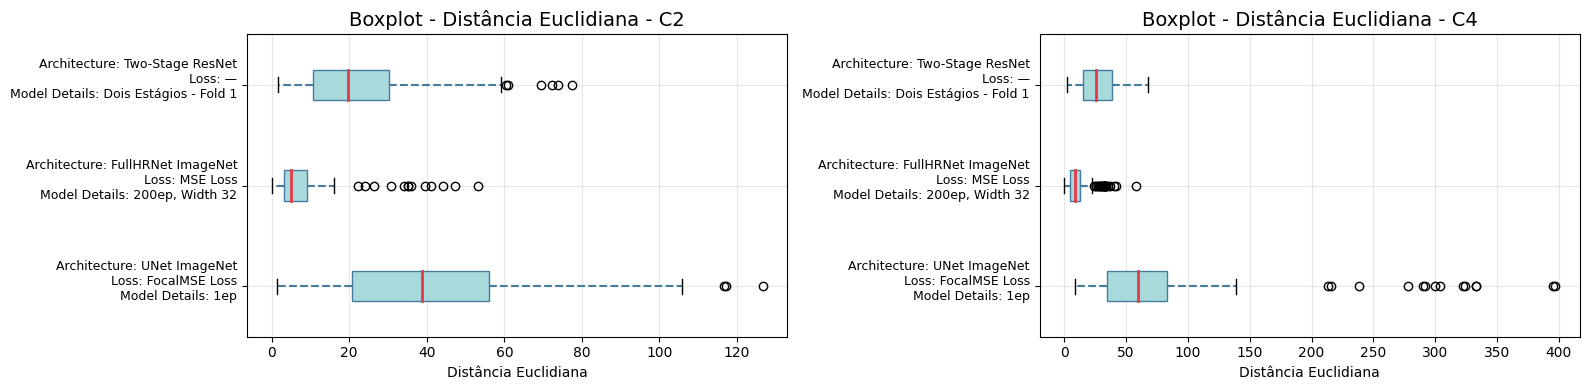

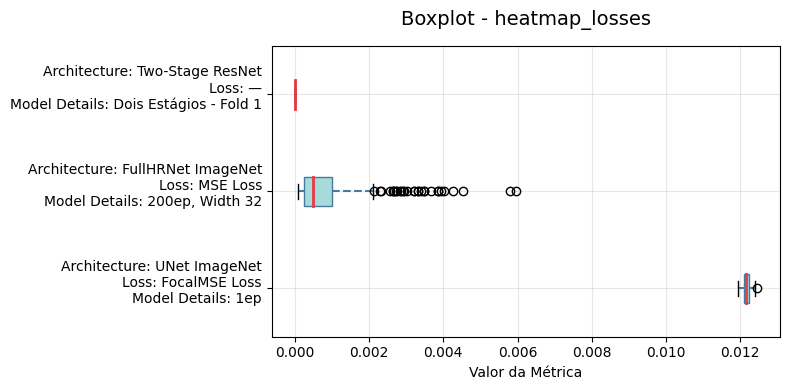

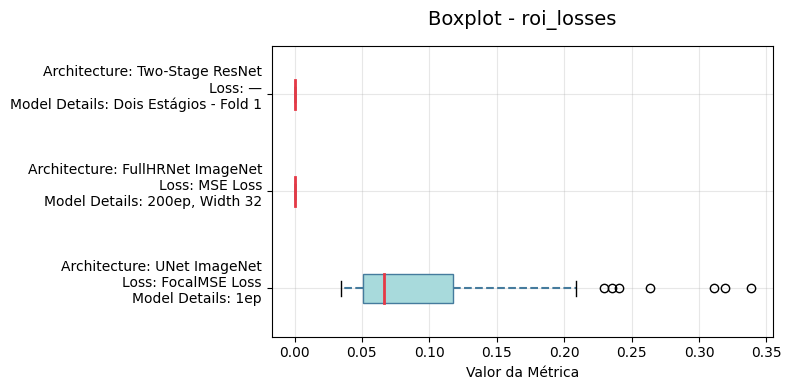

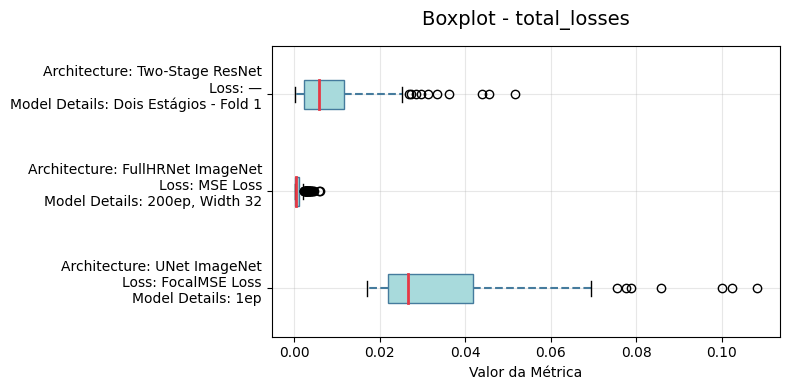

In [5]:
# Boxplot das Métricas
comp.plot_boxplot_metrics(["keypoint_distances", "heatmap_losses", "roi_losses", "total_losses"])

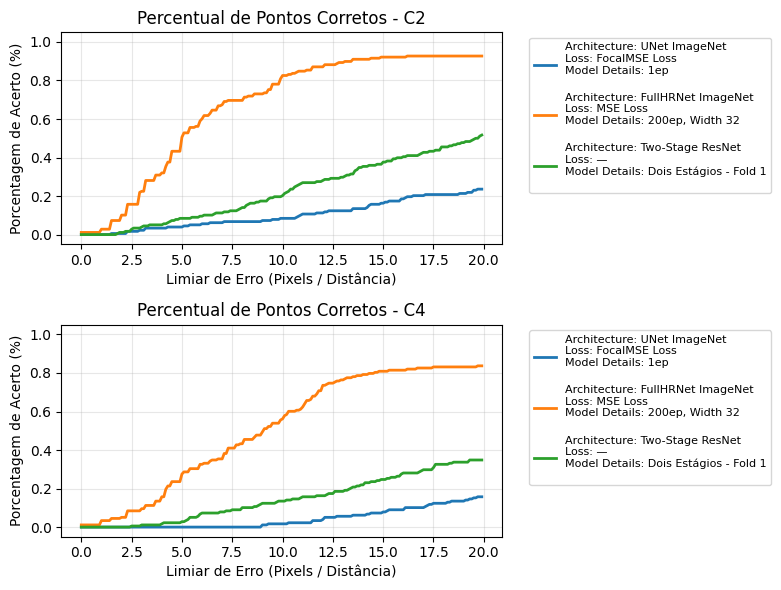

: 

In [ ]:
# Percentual de Pontos Corretos
comp.plot_percentage_correct_keypoint()

### **Comparação em Vídeo**

#### **Visualizador em janela separada (tempo real)**

Abre uma janela fora do notebook. Ligue/desligue cada modelo pelos checkboxes (vários ao mesmo tempo); só os modelos ativos são inferidos em cada frame.

Atalhos: **Espaço** = play/pause, **← / →** = frame anterior/próximo.

In [ ]:
import glob
from src.evalutation.video_viewer_launcher import launch_viewer

video_files = glob.glob(r"data\videos\*")
video_path  = video_files[0]
print(f"Vídeo selecionado: {video_path}")

# Abre em processo separado — o notebook continua livre.
# Erros da janela ficam em video_viewer.log (raiz do projeto).
proc = launch_viewer(video_path, list_models_single_stage, list_models_two_stage)

#### **Métricas de tempo no notebook (opcional)**

In [ ]:
import glob
from src.evalutation.video_comparator import VideoComparator

# Seleciona automaticamente o primeiro vídeo em data/videos/
video_files = glob.glob(r"data\videos\*")
video_path  = video_files[0]  # altere o índice para escolher outro vídeo
print(f"Vídeo selecionado: {video_path}")

# Cria o comparador de vídeo usando o mesmo dict_config das células anteriores
# (pre-processa todos os frames de uma vez para cada modelo)
vc = VideoComparator(dict_config=dict_config, video_path=video_path)

In [ ]:
# ── Widget interativo ─────────────────────────────────────────────────────
# Selecione um ou mais modelos na lista (Ctrl/Cmd para múltipla seleção)
# Use ▶ ou arraste o slider para navegar pelos frames
vc.display_interactive()

In [ ]:
# ── Gráficos de tempo de inferência ──────────────────────────────────────
# Boxplot por modelo + barra de média ± desvio padrão + tabela de FPS
vc.plot_timing_metrics()